# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuicao Fisica**

---

# **Aula 4 — Modelagem matematica do CVRP (Parte 2)**
**Grupo 2** — Rodrigo Pimentel, Bernardo Caula, Joao Felipe Leal, Lucas Campos, Lucas Terzi

---

## Objetivos

1. Carregar instancia preparada na Aula 2;
2. Definir parametros logisticos com **frota heterogenea** (Fiorino + VUC);
3. Construir modelo matematico com variaveis indexadas por tipo de veiculo;
4. Implementar **MTZ (Miller-Tucker-Zemlin)** para eliminacao de subtours;
5. Resolver e comparar desempenho com a Aula 3 (sem MTZ);
6. Interpretar solucao e validar operacionalmente.

**Evolucao em relacao a Aula 3:**

- Aula 3: frota homogenea (so VUC), sem eliminacao de subtours → solucoes com ciclos desconectados.
- Aula 4: frota heterogenea (Fiorino + VUC), restricoes MTZ → solucoes conectadas ao deposito.

Mais realismo → mais restricoes/variaveis → maior custo computacional.

In [24]:
# ============================================================
# (1) IMPORTS E SELECAO DA INSTANCIA
# ============================================================
# Adaptado para execucao local (Jupyter Lab).
# Os dados foram preparados na Aula 2.
# ============================================================

import numpy as np
import pandas as pd
import json
import os
import time
import matplotlib.pyplot as plt

from pyomo.environ import *
from pyomo.opt import SolverFactory
from collections import defaultdict

# ============================================================
# Selecao da instancia a ser analisada
# Altere INSTANCIA para rodar diferentes cenarios.
# ============================================================

INSTANCIA = "Equipe_2_C1_10"   # opcoes: Equipe_2_C1_10, Equipe_2_C2_25, Equipe_2_C3_40, Equipe_2_C4_60

DATA_DIR = os.path.join("..", "..", "2", "datasets", INSTANCIA)

print(f"Instancia selecionada: {INSTANCIA}")
print(f"Diretorio: {DATA_DIR}")
print(f"Arquivos disponiveis: {os.listdir(DATA_DIR)}")

Instancia selecionada: Equipe_2_C1_10
Diretorio: ..\..\2\datasets\Equipe_2_C1_10
Arquivos disponiveis: ['Cvar.npy', 'D.npy', 'nodes.csv', 'params.json', 'q.npy', 's.npy', 'Tmov_h.npy']


In [25]:
# ============================================================
# (2) LEITURA E VALIDACAO DA INSTANCIA
# ============================================================
# Antes de modelar, VALIDAMOS os dados.
# Se a base estiver inconsistente, o solver pode:
# - declarar inviabilidade, ou
# - "resolver" algo que nao representa a operacao real.
# ============================================================

nodes = pd.read_csv(os.path.join(DATA_DIR, "nodes.csv"))
D = np.load(os.path.join(DATA_DIR, "D.npy"))
C = np.load(os.path.join(DATA_DIR, "Cvar.npy"))
q = np.load(os.path.join(DATA_DIR, "q.npy"))
s = np.load(os.path.join(DATA_DIR, "s.npy"))

n = len(nodes)

assert D.shape == (n, n), "Dimensao incorreta de D"
assert C.shape == (n, n), "Dimensao incorreta de C"
assert q.shape == (n,), "Dimensao incorreta de q"
assert s.shape == (n,), "Dimensao incorreta de s"
assert nodes.loc[0, "id"] == 0, "No 0 deve ser o deposito"

print(f"Instancia carregada: {n-1} clientes + deposito")
print(f"Demanda total (kg): {q[1:].sum():.1f}")
print(f"Maior demanda (kg): {q[1:].max():.1f}")

Instancia carregada: 10 clientes + deposito
Demanda total (kg): 141.6
Maior demanda (kg): 53.0


In [26]:
# ======================================================
# (3) PARAMETROS LOGISTICOS - FROTA HETEROGENEA
# ======================================================
# Nesta aula, saimos do cenario homogeneo (Aula 3) e aproximamos da operacao:
# - dois tipos de veiculo (Fiorino e VUC)
# - capacidades diferentes
# - custos fixos diferentes
#
# Q[k]  -> capacidade do tipo k (kg)
# f[k]  -> custo fixo diario do tipo k (R$)
# H     -> limite operacional de jornada (h)
# v_kmh -> velocidade media (km/h)
# T     -> matriz de tempos de viagem (h), derivada de D (km)
#
# VUC: Maior capacidade, maior custo fixo
# Fiorino: Menor capacidade, menor custo
# ======================================================

# Tipos de veiculos
vehicle_types = ["FIO", "VUC"]

Q = {
    "FIO": 650.0,
    "VUC": 3000.0
}

f = {
    "FIO": 250.0,
    "VUC": 550.0
}

H = 8.0
v_kmh = 40.0

# Usaremos H=8h como referencia OPERACIONAL e faremos
# uma checagem pos-solucao por rota/veiculo (validacao).

T = D / v_kmh

print(f"Tipos de veiculos: {vehicle_types}")
print(f"Capacidades: {Q}")
print(f"Custos fixos: {f}")
print(f"Jornada maxima (referencia): {H} h")

Tipos de veiculos: ['FIO', 'VUC']
Capacidades: {'FIO': 650.0, 'VUC': 3000.0}
Custos fixos: {'FIO': 250.0, 'VUC': 550.0}
Jornada maxima (referencia): 8.0 h


In [27]:
# ============================================================
# (4) CONSTRUCAO DO MODELO
# ============================================================
# Conjuntos:
# N -> nos (0 = deposito; 1..n-1 = clientes)
# C -> clientes
# K -> veiculos (tipos distintos)
# A -> arcos (i,j,k): decisao de o veiculo k ir de i para j
#
# Na Aula 3, detectavamos subtours.
# Na Aula 4, vamos ELIMINAR subtours (MTZ).
# ============================================================

model = ConcreteModel()

model.N = RangeSet(0, n-1)
model.C = RangeSet(1, n-1)
model.K = Set(initialize=vehicle_types)

model.A = [(i,j,k) for i in range(n)
                     for j in range(n)
                     for k in vehicle_types
                     if i != j]

model.x = Var(model.A, domain=Binary)

# Observacao:
# Nesta versao, K representa tipos/decisoes de frota (simplificacao).
# Uma modelagem mais fiel com 3 Fiorinos + 1 VUC exigiria veiculos individuais
# (ex.: K = {FIO1, FIO2, FIO3, VUC1}), aumentando o tamanho do modelo.

print(f"Numero de arcos (|A|): {len(model.A)}")
print(f"Variaveis binarias x[i,j,k]: {len(model.A)}")

Numero de arcos (|A|): 220
Variaveis binarias x[i,j,k]: 220


In [28]:
# ============================================================
# (5) VARIAVEIS AUXILIARES (MTZ)
# ============================================================
# u[i] e uma variavel auxiliar que impoe uma "ordem" de visita do cliente i.
# Ela NAO mede distancia; mede posicao relativa.
#
# Intuicao:
# - se cada cliente tiver uma posicao coerente na sequencia,
#   nao conseguimos formar um ciclo fechado desconectado do deposito.
# ============================================================

model.u = Var(model.C, bounds=(1, n-1))

In [29]:
# ============================================================
# (6) NUMERO DE VEICULOS POR TIPO
# ============================================================
# Introduzimos uma variavel binaria y[k].
# y[k] = 1 indica que o veiculo tipo k foi utilizado.
# Isso representa melhor o custo fixo operacional: o veiculo e acionado ou nao.
# ============================================================

# Variavel binaria de ativacao do veiculo
model.y = Var(model.K, domain=Binary)

# Se um veiculo sai do deposito, ele deve ser ativado.
def activate_vehicle_rule(model, k):
    return sum(model.x[0,j,k] for j in model.C) <= model.y[k]

# Se o veiculo retorna ao deposito, ele tambem deve estar ativado.
def activate_return_rule(model, k):
    return sum(model.x[i,0,k] for i in model.C) <= model.y[k]

model.activate_vehicle = Constraint(model.K, rule=activate_vehicle_rule)
model.activate_return = Constraint(model.K, rule=activate_return_rule)

In [30]:
# ============================================================
# (7) FUNCAO OBJETIVO
# ============================================================
# Otimizamos custo total:
# - custo variavel (deslocamento) + custo fixo (ativacao de veiculo)
#
# Trade-off tipico:
# - usar um VUC (custo fixo maior) pode reduzir o numero de veiculos e viagens
# - usar Fiorinos (custo fixo menor) pode exigir mais rotas/quilometragem
# ============================================================

def obj_rule(model):
    travel_cost = sum(C[i,j] * model.x[i,j,k] for (i,j,k) in model.A)
    fixed_cost = sum(f[k] * model.y[k] for k in model.K)
    return travel_cost + fixed_cost

model.obj = Objective(rule=obj_rule, sense=minimize)

In [31]:
# ============================================================
# (8) RESTRICOES DE ATENDIMENTO (GRAU)
# ============================================================
# Cada cliente deve ser atendido exatamente UMA vez.
#
# (1) Deve existir exatamente UMA saida do cliente (o veiculo sai apos atende-lo).
# (2) Deve existir exatamente UMA entrada no cliente (algum veiculo chega para atende-lo).
#
# Mesmo garantindo entrada e saida unicas, ainda podem existir ciclos
# desconectados do deposito. Grau local != conectividade global.
# O MTZ corrigira isso depois.
# ============================================================

# SAIDA UNICA POR CLIENTE
def out_rule(model, i):
    return sum(
        model.x[i, j, k]
        for j in model.N if j != i
        for k in model.K
    ) == 1

model.out = Constraint(model.C, rule=out_rule)

# ENTRADA UNICA POR CLIENTE
def in_rule(model, j):
    return sum(
        model.x[i, j, k]
        for i in model.N if i != j
        for k in model.K
    ) == 1

model.inn = Constraint(model.C, rule=in_rule)

In [32]:
# ============================================================
# (9) BALANCO NO DEPOSITO
# ============================================================
# Para cada veiculo k:
# - o numero de saidas do deposito deve igualar o numero de retornos
#
# Garante consistencia no deposito, mas ainda NAO impede subtours.

def depot_balance(model, k):
    return sum(model.x[0,j,k] for j in model.C) == \
           sum(model.x[i,0,k] for i in model.C)

model.depot_balance = Constraint(model.K, rule=depot_balance)

# Cada veiculo pode iniciar no maximo uma rota.
# Evita que o mesmo veiculo opere multiplas rotas independentes.

def single_departure_rule(model, k):
    return sum(model.x[0, j, k] for j in model.C) <= 1

model.single_departure = Constraint(model.K, rule=single_departure_rule)

In [33]:
# ============================================================
# (10) CAPACIDADE AGREGADA HETEROGENEA
# ============================================================
# Check agregado:
# - demanda total <= capacidade total disponibilizada pelos veiculos ativados
#
# Atencao: isso NAO garante que cada veiculo individualmente respeite
# sua capacidade (isso exigiria restricoes por veiculo/rota).
# ============================================================

def capacity_rule(model):
    total_demand = sum(q[i] for i in range(1,n))
    total_capacity = sum(Q[k] * model.y[k] for k in vehicle_types)
    return total_demand <= total_capacity

model.capacity = Constraint(rule=capacity_rule)

In [34]:
# ============================================================
# (11) CONSERVACAO DE FLUXO POR VEICULO (ESSENCIAL NO HETEROGENEO)
# ============================================================
# Para cada veiculo k e cliente i:
# - tudo que entra em i pelo veiculo k deve sair de i pelo mesmo veiculo k
#
# Isso forca a rota do veiculo a ser "continua localmente".
# Mas conectividade GLOBAL ainda nao esta garantida → subtours podem surgir.
# ============================================================

def flow_by_type_rule(model, i, k):
    return sum(model.x[i,j,k] for j in model.N if j != i) - \
           sum(model.x[j,i,k] for j in model.N if j != i) == 0

model.flow_by_type = Constraint(model.C, model.K, rule=flow_by_type_rule)

In [35]:
# ============================================================
# (12) MTZ — ELIMINACAO DE SUBTOURS
# ============================================================
# Adicionamos a restricao que faltava na Aula 3: conectividade global.
#
# u[i] - u[j] + (n-1)*sum_k x[i,j,k] <= n-2
#
# Interpretacao:
# Se o arco i->j e usado, entao j deve estar "depois" de i na ordem.
#
# Utilizamos uma unica variavel u[i] compartilhada entre veiculos.
# Essa e uma simplificacao para reduzir o tamanho do modelo.
# ============================================================

def mtz_rule(model, i, j):
    if i == j:
        return Constraint.Skip
    return model.u[i] - model.u[j] + (n-1)*sum(model.x[i,j,k] for k in model.K) <= n-2

model.mtz = Constraint(model.C, model.C, rule=mtz_rule)

In [36]:
# ============================================================
# (13) COMPLEXIDADE — MEDINDO O TAMANHO DO PROBLEMA
# ============================================================
# Compare com a Aula 3:
# so acrescentar dimensao de veiculo + MTZ ja muda muito a escala.
# ============================================================

print(f"Variaveis binarias x[i,j,k]: {len(model.A)}")
print(f"Clientes: {n-1}")
print(f"Tipos de veiculos: {vehicle_types}")
print(f"Numero de restricoes: {len(list(model.component_data_objects(Constraint)))}")

Variaveis binarias x[i,j,k]: 220
Clientes: 10
Tipos de veiculos: ['FIO', 'VUC']
Numero de restricoes: 139


In [37]:
# ============================================================
# (14) ESCOLHA DO SOLVER E RESOLUCAO
# ============================================================
# Utilizamos Gurobi com licenca academica da PUC-Rio.
# ============================================================

SOLVER_NAME = "gurobi"

solver = SolverFactory(SOLVER_NAME)

if not solver.available():
    raise RuntimeError(f"O solver {SOLVER_NAME} nao esta disponivel.")

solver.options["TimeLimit"] = 300  # 5 minutos

print(f"Resolvendo com solver: {SOLVER_NAME}")

start_time = time.time()
results = solver.solve(model, tee=True)
end_time = time.time()

elapsed = end_time - start_time

print(f"\nStatus: {results.solver.status}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"Tempo de solucao: {elapsed:.2f} segundos")
print(f"Custo total: R$ {value(model.obj):.2f}")

for k in model.K:
    print(f"Veiculo tipo {k}: y={int(value(model.y[k]))}")

Resolvendo com solver: gurobi
Read LP format model from file C:\Users\rodri\AppData\Local\Temp\tmp1594ev5r.pyomo.lp
Reading time = 0.01 seconds
x1: 139 rows, 232 columns, 1266 nonzeros
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 139 rows, 232 columns and 1266 nonzeros (Min)
Model fingerprint: 0x42befacb
Model has 222 linear objective coefficients
Variable types: 10 continuous, 222 integer (222 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [2e-02, 6e+02]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 1e+02]

Found heuristic solution: objective 1133.1731167
Presolve removed 2 rows and 0 columns
Presolve time: 0.00s
Presolved: 137 rows, 232 co

In [38]:
# ============================================================
# (15) EXTRACAO DOS ARCOS SELECIONADOS
# ============================================================
# Apos resolver, extraimos os arcos (i,j,k) com x=1.

selected_arcs = [(i,j,k) for (i,j,k) in model.A
                 if value(model.x[i,j,k]) > 0.5]

print(f"Total de arcos selecionados: {len(selected_arcs)}")
print(f"Arcos: {selected_arcs[:20]}")

Total de arcos selecionados: 11
Arcos: [(0, 2, 'FIO'), (1, 7, 'FIO'), (2, 8, 'FIO'), (3, 9, 'FIO'), (4, 10, 'FIO'), (5, 0, 'FIO'), (6, 1, 'FIO'), (7, 5, 'FIO'), (8, 3, 'FIO'), (9, 4, 'FIO'), (10, 6, 'FIO')]


In [39]:
# ============================================================
# (16) RECONSTRUCAO DAS ROTAS POR VEICULO
# ============================================================
# Transformamos a lista de arcos em sequencia (rota) por veiculo.
# Este passo e pos-processamento — essencial para validar operacionalmente.
# ============================================================

succ = defaultdict(dict)

for (i,j,k) in selected_arcs:
    succ[k][i] = j

routes = []

for k in model.K:
    starts = [j for (i,j,kk) in selected_arcs if i == 0 and kk == k]

    for start in starts:
        route = [0, start]
        current = start

        while current != 0:
            next_node = succ[k].get(current, None)
            if next_node is None:
                break
            route.append(next_node)
            current = next_node

        routes.append((k, route))

print("Rotas reconstruidas:")
for idx, (k, r) in enumerate(routes, 1):
    clients = [node for node in r if node != 0]
    print(f"  Rota {idx} [{k}] ({len(clients)} clientes): {r}")

Rotas reconstruidas:
  Rota 1 [FIO] (10 clientes): [0, 2, 8, 3, 9, 4, 10, 6, 1, 7, 5, 0]


In [40]:
# ============================================================
# (17) VALIDACAO POS-SOLUCAO — JORNADA POR VEICULO/ROTA
# ============================================================
# Como a jornada NAO foi imposta no MIP,
# validamos aqui se cada rota/veiculo respeita H = 8h.
#
# Tempo total da rota = (tempo de deslocamento) + (tempo de servico)
# ============================================================

def route_time(route):
    t_mov = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a+1]
        t_mov += T[i, j]

    clients = [node for node in route if node != 0]
    t_serv = sum(s[i] for i in clients)
    t_total = t_mov + t_serv

    return t_total, t_mov, t_serv, clients

print(f"Limite operacional (referencia): H = {H:.2f} h\n")

violations = 0
all_visited = set()

for r_id, (k, r) in enumerate(routes, start=1):
    t_total, t_mov, t_serv, clients = route_time(r)
    all_visited.update(clients)

    status = "OK" if t_total <= H + 1e-6 else "VIOLA"
    if status == "VIOLA":
        violations += 1

    n_clients = len(clients)
    print(f"[{k}] Rota {r_id}: {n_clients} clientes | tempo total = {t_total:.2f} h (mov={t_mov:.2f}, serv={t_serv:.2f}) -> {status}")

print(f"\nTotal de rotas que violam H: {violations}")

missing = set(range(1, n)) - all_visited
if missing:
    print(f"\nATENCAO: Clientes nao atendidos nas rotas reconstruidas: {sorted(missing)}")
else:
    print("\nChecagem de atendimento: OK (todos os clientes aparecem nas rotas).")

Limite operacional (referencia): H = 8.00 h

[FIO] Rota 1: 10 clientes | tempo total = 5.37 h (mov=2.87, serv=2.50) -> OK

Total de rotas que violam H: 0

Checagem de atendimento: OK (todos os clientes aparecem nas rotas).


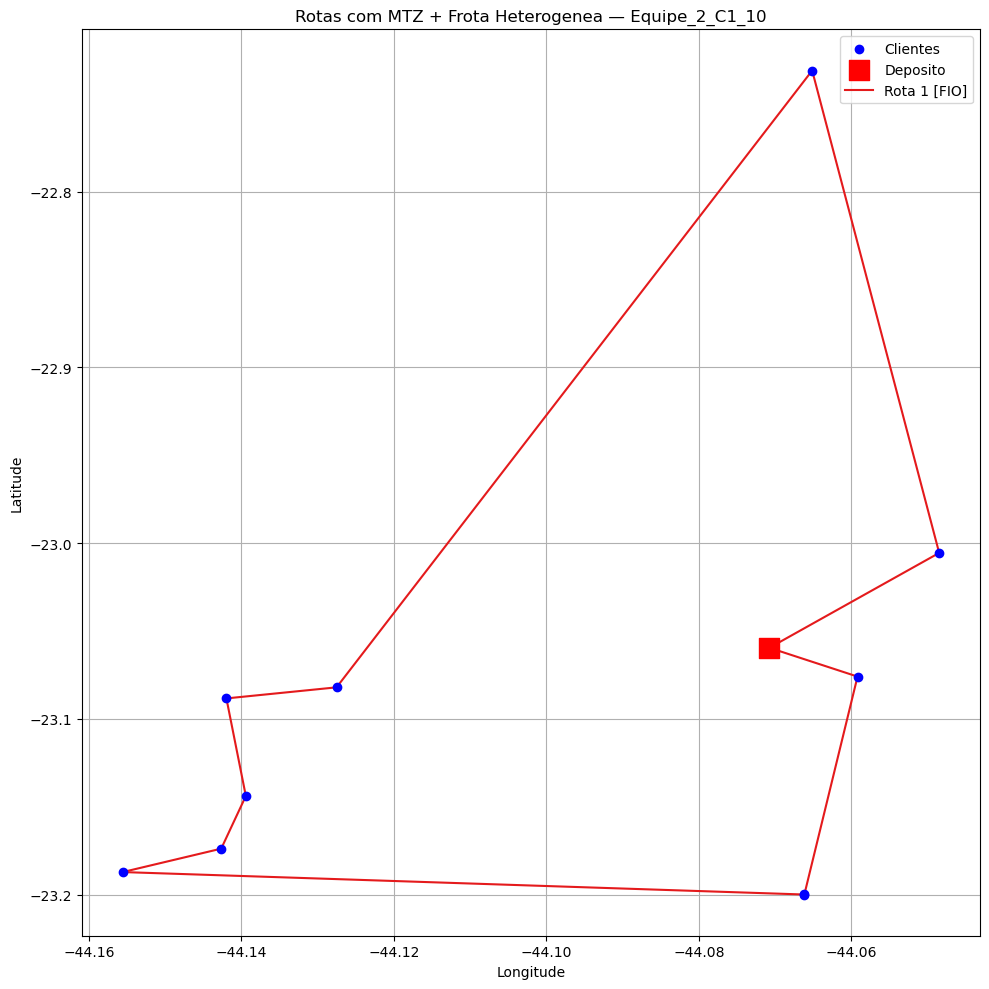

In [41]:
# ============================================================
# (18) VISUALIZACAO
# ============================================================
# Ferramenta de validacao:
# - existe rota desconectada?
# - todos saem e retornam ao deposito?
# - MTZ funcionou (subtours desapareceram)?
# ============================================================

x_coords = nodes["lon"].values
y_coords = nodes["lat"].values

colors = plt.cm.Set1.colors

plt.figure(figsize=(10,10))

plt.scatter(x_coords[1:], y_coords[1:], color='blue', zorder=5, label='Clientes')
plt.scatter(x_coords[0], y_coords[0], color='red', s=200, zorder=5, marker='s', label='Deposito')

for idx, (k, route) in enumerate(routes):
    color = colors[idx % len(colors)]
    for i in range(len(route)-1):
        i_node = route[i]
        j_node = route[i+1]
        plt.plot([x_coords[i_node], x_coords[j_node]],
                 [y_coords[i_node], y_coords[j_node]],
                 color=color, linewidth=1.5,
                 label=f"Rota {idx+1} [{k}]" if i == 0 else "")

plt.title(f"Rotas com MTZ + Frota Heterogenea — {INSTANCIA}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# (19) CHECK OPERACIONAL (AGREGADO)
# ============================================================
# Verificamos coerencia operacional de forma agregada:
# - demanda total vs capacidade total ativada
# - tempos de deslocamento e servico
# ============================================================

total_demand = sum(q[i] for i in range(1,n))
cap_total = sum(Q[k]*value(model.y[k]) for k in vehicle_types)

Tmov_sol = sum(T[i,j]*value(model.x[i,j,k]) for (i,j,k) in model.A)
Tserv = sum(s[i] for i in range(1,n))

print("=== CHECK OPERACIONAL (AGREGADO) ===")
print(f"Demanda total (kg): {total_demand:.1f}")
print(f"Capacidade total disponivel (kg): {cap_total:.1f}")
print(f"Tempo deslocamento da solucao (h): {Tmov_sol:.2f}")
print(f"Tempo de servico total (h): {Tserv:.2f}")
print(f"Tempo total (h): {Tmov_sol+Tserv:.2f}")
print(f"m[VUC] = {int(value(model.y['VUC']))} | m[FIO] = {int(value(model.y['FIO']))}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"\nObs.: H=8h NAO foi imposto no MIP. A jornada esta sendo validada por rota/veiculo.")

=== CHECK OPERACIONAL (AGREGADO) ===
Demanda total (kg): 141.6
Capacidade total disponivel (kg): 650.0
Tempo deslocamento da solucao (h): 2.87
Tempo de servico total (h): 2.50
Tempo total (h): 5.37
m[VUC] = 0 | m[FIO] = 1
Termination condition: optimal

Obs.: H=8h NAO foi imposto no MIP. A jornada esta sendo validada por rota/veiculo.


## Analises de sensibilidade

Experimentos guiados para observar como a solucao reage a mudancas nos parametros.

In [43]:
# ============================================================
# (20) EXPERIMENTOS GUIADOS - ANALISE DE SENSIBILIDADE
# ============================================================

# Salvando parametros originais
Q_original = Q.copy()
f_original = f.copy()

# ============================================================
# EXPERIMENTO 1 — CUSTO FIXO DO VUC
# ============================================================
# Aumentamos o custo fixo do VUC para ver se o modelo troca para Fiorino.

f["VUC"] = 1500.0

results_exp1 = solver.solve(model)

print("=== EXPERIMENTO 1: Custo fixo VUC = R$ 1500 ===")
print(f"Custo total: R$ {value(model.obj):.2f}")
for k in model.K:
    print(f"  {k}: y={int(value(model.y[k]))}")

# ============================================================
# EXPERIMENTO 2 — CAPACIDADE DO VUC
# ============================================================
# Restauramos custo e reduzimos capacidade do VUC.

f["VUC"] = f_original["VUC"]
Q["VUC"] = 1000.0

results_exp2 = solver.solve(model)

print(f"\n=== EXPERIMENTO 2: Capacidade VUC = 1000 kg ===")
print(f"Custo total: R$ {value(model.obj):.2f}")
for k in model.K:
    print(f"  {k}: y={int(value(model.y[k]))}")

# ============================================================
# RESET
# ============================================================
Q = Q_original.copy()
f = f_original.copy()
print("\nParametros restaurados.")

=== EXPERIMENTO 1: Custo fixo VUC = R$ 1500 ===
Custo total: R$ 422.38
  FIO: y=1
  VUC: y=0

=== EXPERIMENTO 2: Capacidade VUC = 1000 kg ===
Custo total: R$ 422.38
  FIO: y=1
  VUC: y=0

Parametros restaurados.


## Perguntas para reflexao

1. Por que as restricoes de grau nao garantem conectividade global?
2. Como o MTZ elimina subtours?
3. Qual foi o impacto computacional da inclusao do MTZ?
4. Por que a frota heterogenea aumenta a complexidade?
5. O modelo garante viabilidade individual por veiculo?
6. O que significa resolver ate otimo?
7. Em um sistema real, voce aguardaria a prova de otimalidade?
8. Qual modelo voce adotaria na pratica?
9. O tipo de solver impacta na qualidade da solucao? Por que?

---

## Experimentos computacionais — Todas as instancias (C1 a C4)

A celula abaixo executa o modelo MILP com MTZ e frota heterogenea para as 4 instancias e consolida os resultados em uma tabela comparativa.

In [44]:
# ============================================================
# (21) EXECUCAO PARA TODAS AS INSTANCIAS
# ============================================================

INSTANCIAS = [
    "Equipe_2_C1_10",
    "Equipe_2_C2_25",
    "Equipe_2_C3_40",
    "Equipe_2_C4_60",
]

vehicle_types_loop = ["FIO", "VUC"]

Q_loop = {"FIO": 650.0, "VUC": 3000.0}
f_loop = {"FIO": 250.0, "VUC": 550.0}
H_max = 8.0
v_media = 40.0

resultados = []

for inst_name in INSTANCIAS:
    print(f"\n{'='*60}")
    print(f"Instancia: {inst_name}")
    print(f"{'='*60}")

    # Carregar dados
    ddir = os.path.join("..", "..", "2", "datasets", inst_name)
    nd = pd.read_csv(os.path.join(ddir, "nodes.csv"))
    Dd = np.load(os.path.join(ddir, "D.npy"))
    Cd = np.load(os.path.join(ddir, "Cvar.npy"))
    qd = np.load(os.path.join(ddir, "q.npy"))
    sd = np.load(os.path.join(ddir, "s.npy"))
    Td = Dd / v_media
    nn = len(nd)

    # Construir modelo
    mdl = ConcreteModel()
    mdl.N = RangeSet(0, nn-1)
    mdl.C = RangeSet(1, nn-1)
    mdl.K = Set(initialize=vehicle_types_loop)

    mdl.A = [(i,j,k) for i in range(nn)
                       for j in range(nn)
                       for k in vehicle_types_loop
                       if i != j]

    mdl.x = Var(mdl.A, domain=Binary)
    mdl.u = Var(mdl.C, bounds=(1, nn-1))
    mdl.y = Var(mdl.K, domain=Binary)

    # Ativacao de veiculos
    def activate_vehicle_loop(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) <= mdl.y[k]
    mdl.activate_vehicle = Constraint(mdl.K, rule=activate_vehicle_loop)

    def activate_return_loop(mdl, k):
        return sum(mdl.x[i,0,k] for i in mdl.C) <= mdl.y[k]
    mdl.activate_return = Constraint(mdl.K, rule=activate_return_loop)

    # Funcao objetivo
    def obj_rule_loop(mdl):
        travel_cost = sum(Cd[i,j] * mdl.x[i,j,k] for (i,j,k) in mdl.A)
        fixed_cost = sum(f_loop[k] * mdl.y[k] for k in mdl.K)
        return travel_cost + fixed_cost
    mdl.obj = Objective(rule=obj_rule_loop, sense=minimize)

    # Restricoes de grau
    def out_rule_loop(mdl, i):
        return sum(mdl.x[i,j,k] for j in mdl.N if j != i for k in mdl.K) == 1
    mdl.out = Constraint(mdl.C, rule=out_rule_loop)

    def in_rule_loop(mdl, j):
        return sum(mdl.x[i,j,k] for i in mdl.N if i != j for k in mdl.K) == 1
    mdl.inn = Constraint(mdl.C, rule=in_rule_loop)

    # Balanco no deposito
    def depot_balance_loop(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) == sum(mdl.x[i,0,k] for i in mdl.C)
    mdl.depot_balance = Constraint(mdl.K, rule=depot_balance_loop)

    # Saida unica por tipo
    def single_departure_loop(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) <= 1
    mdl.single_departure = Constraint(mdl.K, rule=single_departure_loop)

    # Capacidade agregada heterogenea
    def capacity_loop(mdl):
        total_demand = sum(qd[i] for i in range(1, nn))
        total_capacity = sum(Q_loop[k] * mdl.y[k] for k in vehicle_types_loop)
        return total_demand <= total_capacity
    mdl.capacity = Constraint(rule=capacity_loop)

    # Conservacao de fluxo por tipo
    def flow_by_type_loop(mdl, i, k):
        return sum(mdl.x[i,j,k] for j in mdl.N if j != i) - \
               sum(mdl.x[j,i,k] for j in mdl.N if j != i) == 0
    mdl.flow_by_type = Constraint(mdl.C, mdl.K, rule=flow_by_type_loop)

    # MTZ
    def mtz_loop(mdl, i, j):
        if i == j:
            return Constraint.Skip
        return mdl.u[i] - mdl.u[j] + (nn-1)*sum(mdl.x[i,j,k] for k in mdl.K) <= nn-2
    mdl.mtz = Constraint(mdl.C, mdl.C, rule=mtz_loop)

    # Resolver
    slv = SolverFactory("gurobi")
    slv.options["TimeLimit"] = 300

    t0 = time.time()
    res = slv.solve(mdl, tee=False)
    t1 = time.time()
    elapsed_s = t1 - t0

    status = str(res.solver.termination_condition)
    custo = value(mdl.obj)
    y_vuc = int(value(mdl.y["VUC"]))
    y_fio = int(value(mdl.y["FIO"]))

    # Extrair arcos e rotas
    sel_arcs = [(i,j,k) for (i,j,k) in mdl.A if value(mdl.x[i,j,k]) > 0.5]

    suc = defaultdict(dict)
    for (i,j,k) in sel_arcs:
        suc[k][i] = j

    rts = []
    for k in vehicle_types_loop:
        starts = [j for (i,j,kk) in sel_arcs if i == 0 and kk == k]
        for start in starts:
            rt = [0, start]
            cur = start
            while cur != 0:
                nxt = suc[k].get(cur, None)
                if nxt is None:
                    break
                rt.append(nxt)
                cur = nxt
            rts.append((k, rt))

    # Jornada
    n_viola = 0
    for (kk, rt) in rts:
        t_m = sum(Td[rt[a], rt[a+1]] for a in range(len(rt)-1))
        t_s = sum(sd[node] for node in rt if node != 0)
        if t_m + t_s > H_max + 1e-6:
            n_viola += 1

    # Clientes atendidos
    vis = set()
    for (kk, rt) in rts:
        vis.update(node for node in rt if node != 0)

    resultados.append({
        "Instancia": inst_name,
        "Clientes": nn - 1,
        "Demanda (kg)": round(qd[1:].sum(), 1),
        "Custo total (R$)": round(custo, 2),
        "VUC": y_vuc,
        "FIO": y_fio,
        "Rotas": len(rts),
        "Clientes atendidos": len(vis),
        "Violacoes jornada": n_viola,
        "Tempo (s)": round(elapsed_s, 2),
        "Status": status,
    })

    print(f"  Custo: R$ {custo:.2f} | VUC={y_vuc} FIO={y_fio} | Rotas: {len(rts)} | Tempo: {elapsed_s:.2f}s | {status}")

# Tabela comparativa
df_resultados = pd.DataFrame(resultados)
print(f"\n{'='*60}")
print("TABELA COMPARATIVA — METODO EXATO COM MTZ + FROTA HETEROGENEA")
print(f"{'='*60}")
df_resultados


Instancia: Equipe_2_C1_10
  Custo: R$ 422.38 | VUC=0 FIO=1 | Rotas: 1 | Tempo: 0.27s | optimal

Instancia: Equipe_2_C2_25
  Custo: R$ 754.04 | VUC=1 FIO=0 | Rotas: 1 | Tempo: 52.69s | optimal

Instancia: Equipe_2_C3_40
containing a solution
  Custo: R$ 769.65 | VUC=1 FIO=0 | Rotas: 1 | Tempo: 300.73s | maxTimeLimit

Instancia: Equipe_2_C4_60
containing a solution
  Custo: R$ 858.31 | VUC=1 FIO=0 | Rotas: 1 | Tempo: 300.88s | maxTimeLimit

TABELA COMPARATIVA — METODO EXATO COM MTZ + FROTA HETEROGENEA


,Instancia,Clientes,Demanda (kg),Custo total (R$),VUC,FIO,Rotas,Clientes atendidos,Violacoes jornada,Tempo (s),Status
0,Equipe_2_C1_10,10,141.6,422.38,0,1,1,10,0,0.27,optimal
1,Equipe_2_C2_25,25,754.5,754.04,1,0,1,25,1,52.69,optimal
2,Equipe_2_C3_40,40,1295.3,769.65,1,0,1,40,1,300.73,maxTimeLimit
3,Equipe_2_C4_60,60,1958.1,858.31,1,0,1,60,1,300.88,maxTimeLimit


---

## Experimentos Computacionais — Sprint 1 (Aula 5)

Avaliacao sistematica do comportamento do modelo matematico, conforme exigido na Aula 5.

**Experimentos obrigatorios:**
1. Utilizacao e remocao da formulacao MTZ
2. Analise do gap x time limit (30s, 60s, 300s)
3. Comparacao de solvers

**Experimentos opcionais (ja realizados acima):**
- Variacao do custo fixo do VUC (Experimento 1, celula 20)
- Variacao da capacidade do VUC (Experimento 2, celula 20)

In [45]:
# ============================================================
# FUNCOES AUXILIARES PARA OS EXPERIMENTOS DA AULA 5
# ============================================================
# Cada experimento constroi o modelo do zero para garantir
# independencia entre execucoes.
# ============================================================

import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
from pyomo.environ import *
from pyomo.opt import SolverFactory
from collections import defaultdict

INSTANCIAS = [
    "Equipe_2_C1_10",
    "Equipe_2_C2_25",
    "Equipe_2_C3_40",
    "Equipe_2_C4_60",
]

VEHICLE_TYPES = ["FIO", "VUC"]
Q_BASE = {"FIO": 650.0, "VUC": 3000.0}
F_BASE = {"FIO": 250.0, "VUC": 550.0}
V_MEDIA = 40.0
H_MAX = 8.0


def build_cvrp_model(inst_name, use_mtz=True):
    """Constroi modelo MILP do CVRP com frota heterogenea (FIO + VUC)."""

    ddir = os.path.join("..", "..", "2", "datasets", inst_name)
    nd = pd.read_csv(os.path.join(ddir, "nodes.csv"))
    Dd = np.load(os.path.join(ddir, "D.npy"))
    Cd = np.load(os.path.join(ddir, "Cvar.npy"))
    qd = np.load(os.path.join(ddir, "q.npy"))
    sd = np.load(os.path.join(ddir, "s.npy"))
    Td = Dd / V_MEDIA
    nn = len(nd)

    mdl = ConcreteModel()
    mdl.N = RangeSet(0, nn-1)
    mdl.C = RangeSet(1, nn-1)
    mdl.K = Set(initialize=VEHICLE_TYPES)

    mdl.A = [(i,j,k) for i in range(nn)
                       for j in range(nn)
                       for k in VEHICLE_TYPES
                       if i != j]

    mdl.x = Var(mdl.A, domain=Binary)
    mdl.y = Var(mdl.K, domain=Binary)

    if use_mtz:
        mdl.u = Var(mdl.C, bounds=(1, nn-1))

    # Ativacao de veiculos
    def activate_veh(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) <= mdl.y[k]
    mdl.activate_vehicle = Constraint(mdl.K, rule=activate_veh)

    def activate_ret(mdl, k):
        return sum(mdl.x[i,0,k] for i in mdl.C) <= mdl.y[k]
    mdl.activate_return = Constraint(mdl.K, rule=activate_ret)

    # Funcao objetivo
    def obj_rule(mdl):
        travel = sum(Cd[i,j] * mdl.x[i,j,k] for (i,j,k) in mdl.A)
        fixed = sum(F_BASE[k] * mdl.y[k] for k in mdl.K)
        return travel + fixed
    mdl.obj = Objective(rule=obj_rule, sense=minimize)

    # Restricoes de grau
    def out_rule(mdl, i):
        return sum(mdl.x[i,j,k] for j in mdl.N if j != i for k in mdl.K) == 1
    mdl.out = Constraint(mdl.C, rule=out_rule)

    def in_rule(mdl, j):
        return sum(mdl.x[i,j,k] for i in mdl.N if i != j for k in mdl.K) == 1
    mdl.inn = Constraint(mdl.C, rule=in_rule)

    # Balanco no deposito
    def depot_bal(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) == sum(mdl.x[i,0,k] for i in mdl.C)
    mdl.depot_balance = Constraint(mdl.K, rule=depot_bal)

    def single_dep(mdl, k):
        return sum(mdl.x[0,j,k] for j in mdl.C) <= 1
    mdl.single_departure = Constraint(mdl.K, rule=single_dep)

    # Capacidade agregada
    def cap_rule(mdl):
        return sum(qd[i] for i in range(1, nn)) <= sum(Q_BASE[k] * mdl.y[k] for k in VEHICLE_TYPES)
    mdl.capacity = Constraint(rule=cap_rule)

    # Conservacao de fluxo por tipo
    def flow_rule(mdl, i, k):
        return sum(mdl.x[i,j,k] for j in mdl.N if j != i) - \
               sum(mdl.x[j,i,k] for j in mdl.N if j != i) == 0
    mdl.flow_by_type = Constraint(mdl.C, mdl.K, rule=flow_rule)

    # MTZ
    if use_mtz:
        def mtz_rule(mdl, i, j):
            if i == j:
                return Constraint.Skip
            return mdl.u[i] - mdl.u[j] + (nn-1)*sum(mdl.x[i,j,k] for k in mdl.K) <= nn-2
        mdl.mtz = Constraint(mdl.C, mdl.C, rule=mtz_rule)

    return mdl, nn, nd, Dd, Cd, qd, sd, Td


def solve_model(mdl, solver_name="gurobi", time_limit=300, extra_opts=None):
    """Resolve o modelo com o solver e time limit especificados."""
    slv = SolverFactory(solver_name)
    if not slv.available():
        return None, 0

    # Nome da opcao de time limit varia por solver
    if "gurobi" in solver_name:
        slv.options["TimeLimit"] = time_limit
    elif solver_name == "cbc":
        slv.options["seconds"] = time_limit
    elif solver_name == "glpk":
        slv.options["tmlim"] = time_limit
    elif "highs" in solver_name:
        slv.options["time_limit"] = time_limit

    if extra_opts:
        for k, v in extra_opts.items():
            slv.options[k] = v

    t0 = time.time()
    res = slv.solve(mdl, tee=False)
    t1 = time.time()

    return res, t1 - t0


def extract_arcs(mdl):
    """Extrai arcos selecionados (x > 0.5)."""
    return [(i,j,k) for (i,j,k) in mdl.A if value(mdl.x[i,j,k]) > 0.5]


def extract_routes(selected_arcs):
    """Reconstroi rotas a partir dos arcos selecionados."""
    succ = defaultdict(dict)
    for (i,j,k) in selected_arcs:
        succ[k][i] = j

    routes = []
    for k in VEHICLE_TYPES:
        starts = [j for (i,j,kk) in selected_arcs if i == 0 and kk == k]
        for start in starts:
            route = [0, start]
            current = start
            while current != 0:
                nxt = succ[k].get(current, None)
                if nxt is None:
                    break
                route.append(nxt)
                current = nxt
            routes.append((k, route))
    return routes


def detect_subtours(selected_arcs, nn):
    """Detecta subtours (ciclos desconectados do deposito)."""
    adj = defaultdict(set)
    for (i,j,k) in selected_arcs:
        adj[i].add(j)

    # BFS a partir do deposito
    depot_reachable = set()
    queue = [0]
    while queue:
        node = queue.pop(0)
        if node in depot_reachable:
            continue
        depot_reachable.add(node)
        for nb in adj[node]:
            if nb not in depot_reachable:
                queue.append(nb)

    # Nos nao alcancaveis formam subtours
    all_nodes = set()
    for (i,j,k) in selected_arcs:
        all_nodes.add(i)
        all_nodes.add(j)

    disconnected = all_nodes - depot_reachable
    if not disconnected:
        return []

    subtours = []
    remaining = disconnected.copy()
    while remaining:
        start = next(iter(remaining))
        component = set()
        stack = [start]
        while stack:
            node = stack.pop()
            if node in component:
                continue
            component.add(node)
            for nb in adj[node]:
                if nb in remaining and nb not in component:
                    stack.append(nb)
        subtours.append(sorted(component))
        remaining -= component

    return subtours


def get_gap(res):
    """Extrai gap de otimalidade dos resultados do solver."""
    try:
        lb = float(res.problem[0].lower_bound)
        ub = float(res.problem[0].upper_bound)
        if abs(ub) > 1e-9:
            return (ub - lb) / abs(ub) * 100
    except:
        pass
    return None


print("Funcoes auxiliares carregadas.")
print(f"Instancias: {INSTANCIAS}")
print(f"Veiculos: {VEHICLE_TYPES}")
print(f"Parametros: Q={Q_BASE}, f={F_BASE}, v={V_MEDIA} km/h")

Funcoes auxiliares carregadas.
Instancias: ['Equipe_2_C1_10', 'Equipe_2_C2_25', 'Equipe_2_C3_40', 'Equipe_2_C4_60']
Veiculos: ['FIO', 'VUC']
Parametros: Q={'FIO': 650.0, 'VUC': 3000.0}, f={'FIO': 250.0, 'VUC': 550.0}, v=40.0 km/h


### Experimento 1: Utilizacao e remocao da formulacao MTZ

Comparacao sistematica do modelo **com** e **sem** as restricoes MTZ para todas as instancias (C1–C4).

Sem MTZ, o solver pode encontrar solucoes com **subtours** (ciclos desconectados do deposito), mesmo que tenham custo menor. Com MTZ, a conectividade global e garantida, ao custo de mais restricoes e maior tempo computacional.

In [46]:
# ============================================================
# EXPERIMENTO 1: COMPARACAO COM/SEM FORMULACAO MTZ
# ============================================================
# Obrigatorio (Aula 5): "Utilizacao e remocao da formulacao MTZ"
#
# Sem MTZ: menos restricoes, solver mais rapido, mas solucoes
# podem conter subtours (ciclos desconectados do deposito).
# Com MTZ: conectividade global garantida, mais restricoes,
# maior custo computacional.
# ============================================================

resultados_mtz = []

for inst_name in INSTANCIAS:
    print(f"\n{'='*60}")
    print(f"Instancia: {inst_name}")
    print(f"{'='*60}")

    for use_mtz in [True, False]:
        label = "COM MTZ" if use_mtz else "SEM MTZ"

        mdl, nn, nd, Dd, Cd, qd, sd, Td = build_cvrp_model(inst_name, use_mtz=use_mtz)
        n_restricoes = len(list(mdl.component_data_objects(Constraint)))
        n_vars = len(mdl.A)

        res, elapsed = solve_model(mdl, "gurobi", time_limit=300)
        status = str(res.solver.termination_condition)

        try:
            custo = value(mdl.obj)
        except:
            custo = None

        sel_arcs = extract_arcs(mdl)
        subtours = detect_subtours(sel_arcs, nn)
        n_subtours = len(subtours)

        gap = get_gap(res)

        resultados_mtz.append({
            "Instancia": inst_name,
            "Clientes": nn - 1,
            "MTZ": label,
            "Custo (R$)": round(custo, 2) if custo else "N/A",
            "Gap (%)": round(gap, 2) if gap is not None else "-",
            "Tempo (s)": round(elapsed, 2),
            "Restricoes": n_restricoes,
            "Subtours": n_subtours,
            "Status": status,
        })

        custo_str = f"R$ {custo:.2f}" if custo else "N/A"
        print(f"  {label}: {custo_str} | Restricoes: {n_restricoes} | "
              f"Subtours: {n_subtours} | Tempo: {elapsed:.2f}s | {status}")

        if n_subtours > 0:
            print(f"    Subtours encontrados: {subtours}")

df_mtz = pd.DataFrame(resultados_mtz)
print(f"\n{'='*60}")
print("TABELA COMPARATIVA — COM vs SEM MTZ")
print(f"{'='*60}")
df_mtz


Instancia: Equipe_2_C1_10
  COM MTZ: R$ 422.38 | Restricoes: 139 | Subtours: 0 | Tempo: 0.79s | optimal
  SEM MTZ: R$ 368.80 | Restricoes: 49 | Subtours: 4 | Tempo: 0.13s | optimal
    Subtours encontrados: [[1, 7], [2, 8], [3, 9], [4, 6, 10]]

Instancia: Equipe_2_C2_25
  COM MTZ: R$ 754.04 | Restricoes: 709 | Subtours: 0 | Tempo: 65.01s | optimal
  SEM MTZ: R$ 666.15 | Restricoes: 109 | Subtours: 11 | Tempo: 0.20s | optimal
    Subtours encontrados: [[1, 7, 17], [2, 18], [3, 9], [4, 10], [5, 20], [6, 19], [8, 12, 21], [13, 22], [14, 25], [15, 24], [16, 23]]

Instancia: Equipe_2_C3_40
containing a solution
  COM MTZ: R$ 769.65 | Restricoes: 1729 | Subtours: 0 | Tempo: 300.98s | maxTimeLimit
  SEM MTZ: R$ 676.69 | Restricoes: 169 | Subtours: 19 | Tempo: 0.17s | optimal
    Subtours encontrados: [[1, 7, 17], [2, 18], [3, 39], [4, 26], [5, 20, 35], [6, 34], [8, 12], [9, 31], [10, 40], [11, 29], [13, 28], [14, 22], [15, 24], [16, 21], [19, 30], [23, 32], [25, 38], [27, 37], [33, 36]]

Ins

,Instancia,Clientes,MTZ,Custo (R$),Gap (%),Tempo (s),Restricoes,Subtours,Status
0,Equipe_2_C1_10,10,COM MTZ,422.38,0.00,0.79,139,0,optimal
1,Equipe_2_C1_10,10,SEM MTZ,368.80,0.00,0.13,49,4,optimal
2,Equipe_2_C2_25,25,COM MTZ,754.04,0.00,65.01,709,0,optimal
3,Equipe_2_C2_25,25,SEM MTZ,666.15,0.00,0.20,109,11,optimal
4,Equipe_2_C3_40,40,COM MTZ,769.65,3.56,300.98,1729,0,maxTimeLimit
5,Equipe_2_C3_40,40,SEM MTZ,676.69,0.00,0.17,169,19,optimal
6,Equipe_2_C4_60,60,COM MTZ,858.31,4.37,300.54,3789,0,maxTimeLimit
7,Equipe_2_C4_60,60,SEM MTZ,734.59,0.00,0.18,249,28,optimal


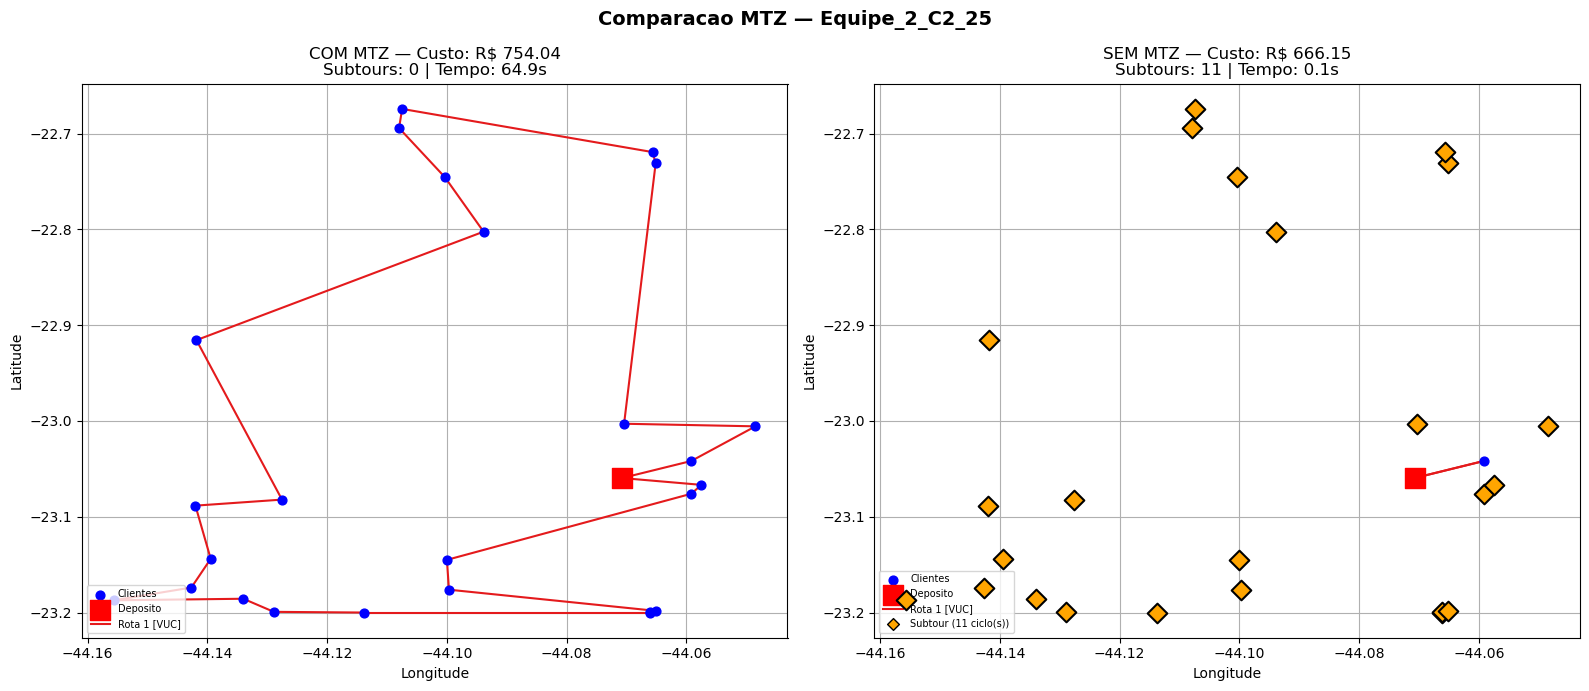

In [47]:
# ============================================================
# VISUALIZACAO: ROTAS COM vs SEM MTZ (INSTANCIA C2)
# ============================================================
# Mostra graficamente a diferenca entre solucoes com e sem MTZ.
# C2 (25 clientes) escolhida por evidenciar subtours sem ser
# grande demais para visualizar.
# ============================================================

inst_viz = "Equipe_2_C2_25"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, use_mtz in enumerate([True, False]):
    ax = axes[idx]
    label = "COM MTZ" if use_mtz else "SEM MTZ"

    mdl, nn, nd, Dd, Cd, qd, sd, Td = build_cvrp_model(inst_viz, use_mtz=use_mtz)
    res, elapsed = solve_model(mdl, "gurobi", time_limit=300)

    sel_arcs = extract_arcs(mdl)
    routes = extract_routes(sel_arcs)
    subtours = detect_subtours(sel_arcs, nn)
    custo = value(mdl.obj)

    x_coords = nd["lon"].values
    y_coords = nd["lat"].values
    colors_plt = plt.cm.Set1.colors

    ax.scatter(x_coords[1:], y_coords[1:], color='blue', zorder=5, s=40, label='Clientes')
    ax.scatter(x_coords[0], y_coords[0], color='red', s=200, zorder=5, marker='s', label='Deposito')

    for r_idx, (k, route) in enumerate(routes):
        color = colors_plt[r_idx % len(colors_plt)]
        for a in range(len(route)-1):
            i_node = route[a]
            j_node = route[a+1]
            ax.plot([x_coords[i_node], x_coords[j_node]],
                    [y_coords[i_node], y_coords[j_node]],
                    color=color, linewidth=1.5,
                    label=f"Rota {r_idx+1} [{k}]" if a == 0 else "")

    # Destaca nos em subtours
    if subtours:
        for st in subtours:
            ax.scatter(x_coords[st], y_coords[st], color='orange', s=100,
                      zorder=6, marker='D', edgecolors='black', linewidth=1.5)
        ax.scatter([], [], color='orange', marker='D', edgecolors='black',
                  label=f'Subtour ({len(subtours)} ciclo(s))')

    ax.set_title(f"{label} — Custo: R$ {custo:.2f}\n"
                 f"Subtours: {len(subtours)} | Tempo: {elapsed:.1f}s")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True)

fig.suptitle(f"Comparacao MTZ — {inst_viz}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Experimento 2: Analise do gap x time limit

Avalia como a qualidade da solucao incumbente evolui com o aumento do tempo disponivel para o solver. Para instancias pequenas (C1, C2) o solver encontra o otimo rapidamente; para instancias maiores (C3, C4), mais tempo geralmente resulta em menor gap de otimalidade.

Time limits testados: **30s, 60s, 300s**.

In [48]:
# ============================================================
# EXPERIMENTO 2: ANALISE DO GAP x TIME LIMIT
# ============================================================
# Obrigatorio: "Limite de tempo"
# Opcional: "Analise do gap x time limit (30s, 60s, 300s)"
#
# Objetivo: avaliar como a qualidade da solucao incumbente
# evolui com o aumento do tempo disponivel para o solver.
# ============================================================

TIME_LIMITS = [30, 60, 300]

resultados_tl = []

for inst_name in INSTANCIAS:
    print(f"\n{'='*60}")
    print(f"Instancia: {inst_name}")
    print(f"{'='*60}")

    for tl in TIME_LIMITS:
        mdl, nn, nd, Dd, Cd, qd, sd, Td = build_cvrp_model(inst_name, use_mtz=True)
        res, elapsed = solve_model(mdl, "gurobi", time_limit=tl)

        status = str(res.solver.termination_condition)

        try:
            custo = value(mdl.obj)
        except:
            custo = None

        gap = get_gap(res)

        resultados_tl.append({
            "Instancia": inst_name,
            "Clientes": nn - 1,
            "TimeLimit (s)": tl,
            "Custo (R$)": round(custo, 2) if custo else "N/A",
            "Gap (%)": round(gap, 2) if gap is not None else "N/A",
            "Tempo real (s)": round(elapsed, 2),
            "Status": status,
        })

        gap_str = f"{gap:.2f}%" if gap is not None else "N/A"
        custo_str = f"R$ {custo:.2f}" if custo else "N/A"
        print(f"  TL={tl:>3}s: {custo_str} | Gap: {gap_str} | "
              f"Tempo: {elapsed:.2f}s | {status}")

df_tl = pd.DataFrame(resultados_tl)
print(f"\n{'='*60}")
print("TABELA — GAP x TIME LIMIT")
print(f"{'='*60}")
df_tl


Instancia: Equipe_2_C1_10
  TL= 30s: R$ 422.38 | Gap: 0.00% | Tempo: 1.08s | optimal
  TL= 60s: R$ 422.38 | Gap: 0.00% | Tempo: 0.47s | optimal
  TL=300s: R$ 422.38 | Gap: 0.00% | Tempo: 0.45s | optimal

Instancia: Equipe_2_C2_25
containing a solution
  TL= 30s: R$ 754.04 | Gap: 0.45% | Tempo: 30.27s | maxTimeLimit
containing a solution
  TL= 60s: R$ 754.04 | Gap: 0.14% | Tempo: 60.38s | maxTimeLimit
  TL=300s: R$ 754.04 | Gap: 0.00% | Tempo: 64.55s | optimal

Instancia: Equipe_2_C3_40
containing a solution
  TL= 30s: R$ 792.17 | Gap: 7.79% | Tempo: 30.53s | maxTimeLimit
containing a solution
  TL= 60s: R$ 776.20 | Gap: 5.80% | Tempo: 60.39s | maxTimeLimit
containing a solution
  TL=300s: R$ 769.65 | Gap: 3.56% | Tempo: 300.92s | maxTimeLimit

Instancia: Equipe_2_C4_60
containing a solution
  TL= 30s: R$ 875.61 | Gap: 7.03% | Tempo: 30.54s | maxTimeLimit
containing a solution
  TL= 60s: R$ 862.20 | Gap: 5.15% | Tempo: 60.46s | maxTimeLimit
containing a solution
  TL=300s: R$ 858.31 | 

,Instancia,Clientes,TimeLimit (s),Custo (R$),Gap (%),Tempo real (s),Status
0,Equipe_2_C1_10,10,30,422.38,0.00,1.08,optimal
1,Equipe_2_C1_10,10,60,422.38,0.00,0.47,optimal
2,Equipe_2_C1_10,10,300,422.38,0.00,0.45,optimal
3,Equipe_2_C2_25,25,30,754.04,0.45,30.27,maxTimeLimit
4,Equipe_2_C2_25,25,60,754.04,0.14,60.38,maxTimeLimit
5,Equipe_2_C2_25,25,300,754.04,0.00,64.55,optimal
6,Equipe_2_C3_40,40,30,792.17,7.79,30.53,maxTimeLimit
7,Equipe_2_C3_40,40,60,776.20,5.80,60.39,maxTimeLimit
8,Equipe_2_C3_40,40,300,769.65,3.56,300.92,maxTimeLimit
9,Equipe_2_C4_60,60,30,875.61,7.03,30.54,maxTimeLimit


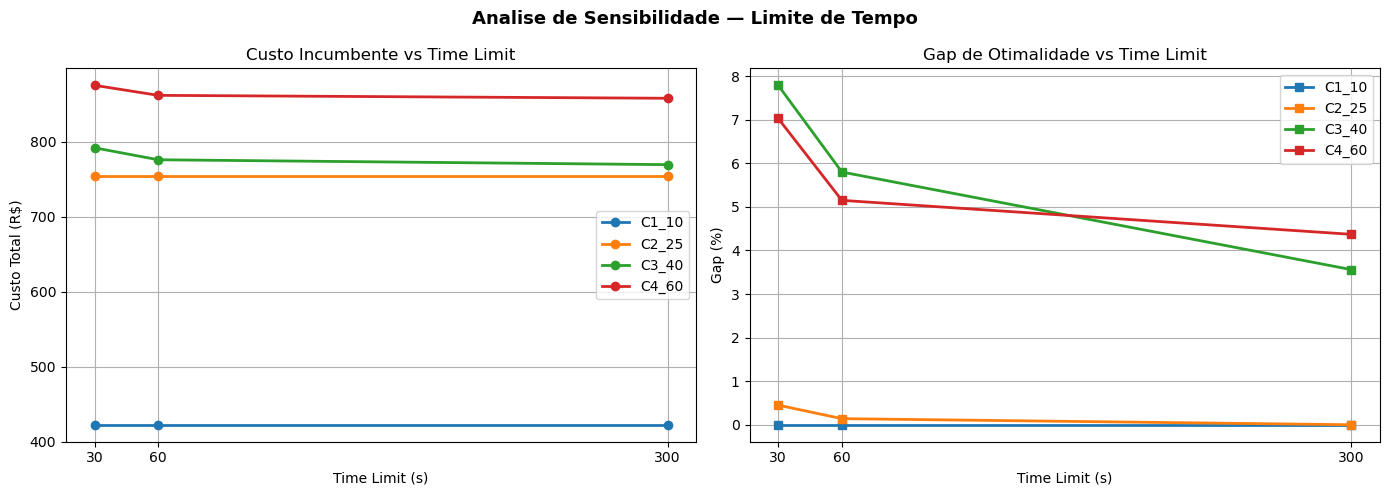

In [49]:
# ============================================================
# VISUALIZACAO: GAP x TIME LIMIT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Custo por time limit
ax1 = axes[0]
for inst in INSTANCIAS:
    subset = df_tl[df_tl["Instancia"] == inst]
    custos = pd.to_numeric(subset["Custo (R$)"], errors="coerce").values
    tls = subset["TimeLimit (s)"].values
    label = inst.replace("Equipe_2_", "")
    ax1.plot(tls, custos, marker='o', linewidth=2, label=label)

ax1.set_xlabel("Time Limit (s)")
ax1.set_ylabel("Custo Total (R$)")
ax1.set_title("Custo Incumbente vs Time Limit")
ax1.legend()
ax1.grid(True)
ax1.set_xticks(TIME_LIMITS)

# Grafico 2: Gap por time limit
ax2 = axes[1]
for inst in INSTANCIAS:
    subset = df_tl[df_tl["Instancia"] == inst]
    gaps = pd.to_numeric(subset["Gap (%)"], errors="coerce").values
    tls = subset["TimeLimit (s)"].values
    label = inst.replace("Equipe_2_", "")
    ax2.plot(tls, gaps, marker='s', linewidth=2, label=label)

ax2.set_xlabel("Time Limit (s)")
ax2.set_ylabel("Gap (%)")
ax2.set_title("Gap de Otimalidade vs Time Limit")
ax2.legend()
ax2.grid(True)
ax2.set_xticks(TIME_LIMITS)

plt.suptitle("Analise de Sensibilidade — Limite de Tempo", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Experimento 3: Comparacao de solvers

Compara o desempenho de diferentes solvers (ou configuracoes de solver) na resolucao do CVRP. Se houver apenas o Gurobi disponivel, compara diferentes estrategias do Gurobi (MIPFocus).

- **MIPFocus=0** (default): balanco entre encontrar solucoes e provar otimalidade.
- **MIPFocus=1**: prioriza encontrar solucoes viaveis rapidamente.
- **MIPFocus=2**: prioriza provar otimalidade (reduzir gap).

Executado apenas nas instancias C1 e C2 para viabilidade de tempo.

In [50]:
# ============================================================
# EXPERIMENTO 3: COMPARACAO DE SOLVERS
# ============================================================
# Obrigatorio (Aula 5): "Solver utilizado"
#
# Compara solvers disponiveis. Se apenas Gurobi estiver
# instalado, compara diferentes estrategias (MIPFocus).
# ============================================================

# Detectar solvers disponiveis
solvers_disponiveis = []
for nome in ["gurobi", "glpk", "cbc", "appsi_highs"]:
    try:
        s = SolverFactory(nome)
        if s.available():
            solvers_disponiveis.append(nome)
    except:
        pass

print(f"Solvers disponiveis: {solvers_disponiveis}")

# Definir configuracoes a testar
if len(solvers_disponiveis) >= 2:
    # Comparar solvers diferentes
    SOLVER_CONFIGS = [(nome, nome, {}) for nome in solvers_disponiveis]
    print(f"\nComparando {len(SOLVER_CONFIGS)} solvers diferentes.")
else:
    # Comparar configuracoes do Gurobi
    SOLVER_CONFIGS = [
        ("Gurobi (default)", "gurobi", {}),
        ("Gurobi MIPFocus=1", "gurobi", {"MIPFocus": 1}),
        ("Gurobi MIPFocus=2", "gurobi", {"MIPFocus": 2}),
    ]
    print("\nApenas Gurobi disponivel. Comparando configuracoes MIPFocus.")

INST_SOLVER = INSTANCIAS[:2]  # C1 e C2 apenas

resultados_solver = []

for inst_name in INST_SOLVER:
    print(f"\n{'='*60}")
    print(f"Instancia: {inst_name}")
    print(f"{'='*60}")

    for label, solver_name, opts in SOLVER_CONFIGS:
        mdl, nn, nd, Dd, Cd, qd, sd, Td = build_cvrp_model(inst_name, use_mtz=True)

        res, elapsed = solve_model(mdl, solver_name, time_limit=300, extra_opts=opts)

        if res is None:
            print(f"  {label}: INDISPONIVEL")
            continue

        status = str(res.solver.termination_condition)

        try:
            custo = value(mdl.obj)
        except:
            custo = None

        gap = get_gap(res)

        resultados_solver.append({
            "Instancia": inst_name,
            "Clientes": nn - 1,
            "Solver": label,
            "Custo (R$)": round(custo, 2) if custo else "N/A",
            "Gap (%)": round(gap, 2) if gap is not None else "N/A",
            "Tempo (s)": round(elapsed, 2),
            "Status": status,
        })

        custo_str = f"R$ {custo:.2f}" if custo else "N/A"
        gap_str = f"{gap:.2f}%" if gap is not None else "N/A"
        print(f"  {label}: {custo_str} | Gap: {gap_str} | Tempo: {elapsed:.2f}s | {status}")

df_solver = pd.DataFrame(resultados_solver)
print(f"\n{'='*60}")
print("TABELA COMPARATIVA — SOLVERS")
print(f"{'='*60}")
df_solver

Solvers disponiveis: ['gurobi', 'appsi_highs']

Comparando 2 solvers diferentes.

Instancia: Equipe_2_C1_10
  gurobi: R$ 422.38 | Gap: 0.00% | Tempo: 0.58s | optimal
  appsi_highs: R$ 422.38 | Gap: 0.01% | Tempo: 6.39s | optimal

Instancia: Equipe_2_C2_25
  gurobi: R$ 754.04 | Gap: 0.00% | Tempo: 77.05s | optimal
load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.
  appsi_highs: R$ 760.18 | Gap: 6.07% | Tempo: 300.23s | maxTimeLimit

TABELA COMPARATIVA — SOLVERS


,Instancia,Clientes,Solver,Custo (R$),Gap (%),Tempo (s),Status
0,Equipe_2_C1_10,10,gurobi,422.38,0.00,0.58,optimal
1,Equipe_2_C1_10,10,appsi_highs,422.38,0.01,6.39,optimal
2,Equipe_2_C2_25,25,gurobi,754.04,0.00,77.05,optimal
3,Equipe_2_C2_25,25,appsi_highs,760.18,6.07,300.23,maxTimeLimit
